# Reactor Type: Packed Bed

Packed-bed reactors (PBRs) are the workhorse of the chemical industry: synthesis of ammonia, methanol, sulfuric acid, hydrocracking, and many more. A fixed bed of catalyst pellets is contacted with a gas or liquid stream. The key phenomena are convection (plug flow approximation), axial dispersion, radial heat/mass transfer, and interphase mass transfer from bulk fluid to catalyst surface.

## Phase structure

| Phase | What it carries | Flow direction |
|---|---|---|
| Fluid (gas/liquid) | Reactants/products, heat | Axial (downward/upward) |
| Solid catalyst | Surface reactants (pseudo-steady) | Stationary |

**Model levels**:
1. **1D pseudo-homogeneous**: single phase, effective properties — simplest
2. **1D heterogeneous**: separate fluid and particle balances
3. **2D pseudo-homogeneous**: adds radial gradients (wall cooling effects)
4. **2D heterogeneous**: most detailed

## Governing equations

**1D pseudo-homogeneous steady-state:**

$$v\frac{dc}{dz} = D_{ax}\frac{d^2c}{dz^2} + (1-\varepsilon)R(c, T)$$

$$\rho_f c_{p,f} v \frac{dT}{dz} = \lambda_{ax}\frac{d^2T}{dz^2} - (1-\varepsilon)(-\Delta H)R(c, T)$$

**Ergun equation** (pressure drop):

$$-\frac{dP}{dz} = \frac{150\mu(1-\varepsilon)^2}{\varepsilon^3 d_p^2}v + \frac{1.75\rho_g(1-\varepsilon)}{\varepsilon^3 d_p}v^2$$

**Axial dispersion** (Edwards & Richardson):

$$\frac{D_{ax}}{v d_p} = \frac{0.73\varepsilon}{\varepsilon + 0.5/(Re\,Sc)} + \frac{0.5}{1 + 9.7\varepsilon/(Re\,Sc)}$$

**External mass transfer** (Wakao & Funazkri):

$$Sh = 2 + 1.1\,Re^{0.6}\,Sc^{1/3}, \quad k_L = Sh\,D_m/d_p$$

## PyMRM modeling strategy

| Term | pymrm function |
|---|---|
| Convective flux | `construct_convflux_upwind` or `interp_cntr_to_stagg_tvd` |
| Axial dispersion | `construct_grad`, `construct_div` with $D_{ax}$ |
| Reaction source | Inline function `R(c, T)` added to residual |
| Pressure drop | Ergun function as extra ODE / auxiliary equation |
| Nonlinear solve | `newton`, `NumJac` |

Shape convention: `c.shape = (Nz, Nc)` — rows are cells, columns are components.

Dax = 4.475e-04 m²/s
kL  = 1.357e-02 m/s,  kLa = 1.628e+01 1/s
Pressure drop: 110.2 Pa over 1.0 m
Da = 8.00,  Bo = 279.3


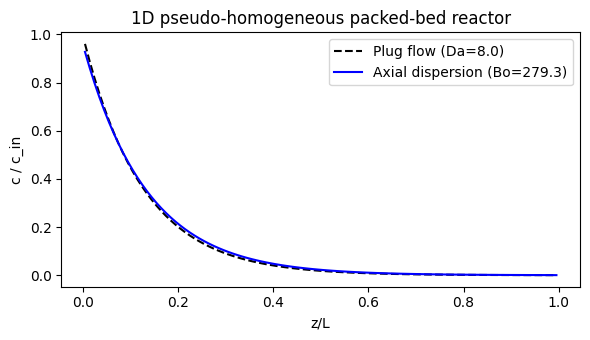

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# ── Closure correlations ──────────────────────────────────────────
def ergun(v_sup, eps, dp, mu, rho):
    '''Pressure gradient [Pa/m], positive = loss.'''
    return (150*mu*(1-eps)**2/(eps**3*dp**2)*v_sup
            + 1.75*rho*(1-eps)/(eps**3*dp)*v_sup**2)

def edwards_richardson(v_int, dp, eps, Dm):
    '''Axial dispersion coefficient [m²/s].'''
    Re = v_int * dp / (Dm / 1e-6 * 1e-6)  # approximate
    Sc = 1.0  # Schmidt number (order 1 for gases)
    return v_int*dp * (0.73*eps/(eps + 0.5/(Re*Sc+1e-9)) + 0.5/(1 + 9.7*eps/(Re*Sc+1e-9)))

def wakao_funazkri(v_sup, dp, eps, Dm, mu, rho):
    '''External mass-transfer coefficient kL [m/s].'''
    Re = rho * v_sup * dp / mu
    Sc = mu / (rho * Dm)
    Sh = 2 + 1.1 * Re**0.6 * Sc**(1/3)
    return Sh * Dm / dp

# ── System parameters ────────────────────────────────────────────
L, N = 1.0, 100
dz = L / N
z  = (np.arange(N) + 0.5) * dz

eps   = 0.40          # void fraction
dp    = 3e-3          # particle diameter [m]
v_sup = 0.05          # superficial velocity [m/s]
mu    = 2e-5          # dynamic viscosity [Pa·s] (gas)
rho   = 1.2           # density [kg/m³]
Dm    = 5e-6          # molecular diffusivity [m²/s]
v_int = v_sup / eps

Dax   = edwards_richardson(v_int, dp, eps, Dm)
kL    = wakao_funazkri(v_sup, dp, eps, Dm, mu, rho)
a_p   = 6*(1-eps)/dp
kLa   = kL * a_p

print(f'Dax = {Dax:.3e} m²/s')
print(f'kL  = {kL:.3e} m/s,  kLa = {kLa:.3e} 1/s')
print(f'Pressure drop: {ergun(v_sup, eps, dp, mu, rho)*L:.1f} Pa over {L} m')

# ── 1D Pseudo-homogeneous steady-state model ──────────────────────
# First-order exothermic reaction: A → B, rate = k * c
k_rxn = 1.0           # [1/s]
c_in  = 1.0           # inlet concentration [mol/m³]
Da    = k_rxn * L / v_int  # Damköhler number
Bo    = v_int * L / Dax    # Bodenstein number
print(f'Da = {Da:.2f},  Bo = {Bo:.1f}')

# Matrix form: v*dc/dz - Dax*d²c/dz² + k*c = 0
off_c = Dax / dz**2
A_c = sp.diags([-off_c - v_int/dz,
                 2*off_c + v_int/dz + k_rxn,
                -off_c],
               [-1, 0, 1], shape=(N, N), format='csr')
rhs_c = np.zeros(N)
rhs_c[0] += (off_c + v_int/dz) * c_in
c_num = spla.spsolve(A_c, rhs_c)

# Analytical (plug flow limit, no dispersion): c = c_in * exp(-Da * z/L)
c_pf = c_in * np.exp(-k_rxn * z / v_int)

plt.figure(figsize=(6, 3.5))
plt.plot(z/L, c_pf, 'k--', label='Plug flow (Da={:.1f})'.format(Da))
plt.plot(z/L, c_num, 'b-',  label=f'Axial dispersion (Bo={Bo:.1f})')
plt.xlabel('z/L'); plt.ylabel('c / c_in')
plt.title('1D pseudo-homogeneous packed-bed reactor')
plt.legend(); plt.tight_layout(); plt.show()

## Sensitivity: Bodenstein number effect

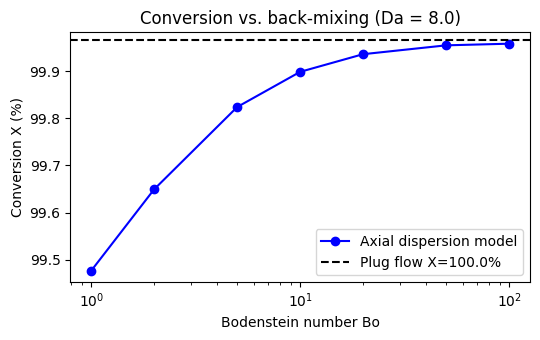

In [2]:
# Effect of axial dispersion on conversion
Bo_vals = [1, 2, 5, 10, 20, 50, 100]
X_conv = []
for Bo_v in Bo_vals:
    Dax_v = v_int * L / Bo_v
    off_v = Dax_v / dz**2
    A_v = sp.diags([-off_v - v_int/dz,
                     2*off_v + v_int/dz + k_rxn,
                    -off_v],
                   [-1, 0, 1], shape=(N, N), format='csr')
    rhs_v = np.zeros(N); rhs_v[0] += (off_v + v_int/dz)*c_in
    c_v = spla.spsolve(A_v, rhs_v)
    X_conv.append(1 - c_v[-1]/c_in)

X_pf = 1 - np.exp(-Da)
plt.figure(figsize=(5.5, 3.5))
plt.semilogx(Bo_vals, [x*100 for x in X_conv], 'bo-', label='Axial dispersion model')
plt.axhline(X_pf*100, color='k', ls='--', label=f'Plug flow X={X_pf*100:.1f}%')
plt.xlabel('Bodenstein number Bo'); plt.ylabel('Conversion X (%)')
plt.title(f'Conversion vs. back-mixing (Da = {Da:.1f})')
plt.legend(); plt.tight_layout(); plt.show()

## Summary

- Ergun equation gives pressure drop; low $\varepsilon$ and small $d_p$ increase $\Delta P$
- Axial dispersion reduces conversion compared with plug flow; effect is small for $Bo > 20$
- External mass transfer (Wakao-Funazkri) is important when $k_L a \sim k_{\text{rxn}}$
- pymrm naturally handles both pseudo-homogeneous (single concentration) and heterogeneous (coupled fluid + particle arrays) formulations